In [1]:
!pip install -q tensorflow kaggle numpy matplotlib scikit-learn seaborn opencv-python


In [2]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)
replace PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/PlantVillage"


In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

print(f"Number of classes: {num_classes}")


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Number of classes: 15


In [5]:
y_train = np.concatenate([labels.numpy() for _, labels in train_ds])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(1.3407226958993097), 1: np.float64(0.9188091263216472), 2: np.float64(1.3656741108354011), 3: np.float64(1.418470790378007), 4: np.float64(8.949051490514906), 5: np.float64(0.6425763767269896), 6: np.float64(1.3759166666666667), 7: np.float64(0.7147619047619047), 8: np.float64(1.4794802867383512), 9: np.float64(0.7675964667596467), 10: np.float64(0.8117502458210423), 11: np.float64(0.9827976190476191), 12: np.float64(0.4354166666666667), 13: np.float64(3.681382385730212), 14: np.float64(0.8784783187017824)}


In [6]:
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,938,527 (22.65 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [13]:
import os
import pickle
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/plant_disease_epoch10.keras"
HISTORY_PATH = "/content/drive/MyDrive/plant_disease_history_epoch10.pkl"

history_data = None

if os.path.exists(MODEL_PATH):
    print("Loading pre-trained model...")
    model = tf.keras.models.load_model(MODEL_PATH)

    # Try loading history safely
    if os.path.exists(HISTORY_PATH) and os.path.getsize(HISTORY_PATH) > 0:
        try:
            with open(HISTORY_PATH, "rb") as f:
                history_data = pickle.load(f)
            print("Training history loaded.")
        except Exception:
            print("History file corrupted. Skipping history plots.")
    else:
        print("No valid history file found. Skipping history plots.")

else:
    print("Training model from scratch...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        class_weight=class_weight_dict
    )

    # Save history safely
    with open(HISTORY_PATH, "wb") as f:
        pickle.dump(history.history, f)

    history_data = history.history


Loading pre-trained model...
No valid history file found. Skipping history plots.


In [14]:
if history_data is not None:
    acc = history_data["accuracy"]
    val_acc = history_data["val_accuracy"]
    loss = history_data["loss"]
    val_loss = history_data["val_loss"]

    epochs = range(len(acc))

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()
else:
    print("Training curves not available (model loaded without history).")


Training curves not available (model loaded without history).


In [15]:
import os
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/PlantVillage"


In [16]:
import os
import numpy as np

image_paths = []
labels = []

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

class_names = sorted(os.listdir(DATA_DIR))
class_to_index = {name: idx for idx, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue

    for fname in os.listdir(class_dir):
        if fname.lower().endswith(VALID_EXTENSIONS):
            image_paths.append(os.path.join(class_dir, fname))
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)

num_classes = len(class_names)

print("Total images:", len(image_paths))
print("Total classes:", num_classes)
print("Unique labels:", len(np.unique(labels)))


Total images: 20638
Total classes: 15
Unique labels: 15


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,   # ✅ KEY LINE
    random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))


Train size: 16510
Validation size: 4128


In [18]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)   # ✅ CORRECT
    return image, label


In [19]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds = (
    train_ds
    .shuffle(buffer_size=len(X_train))
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [20]:
print("Unique train classes:", len(np.unique(y_train)))
print("Unique val classes:", len(np.unique(y_val)))


Unique train classes: 15
Unique val classes: 15


In [21]:
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(
    classification_report(
        y_val,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0
    )
)


129/129 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      1.00      0.99       199
                     Pepper__bell___healthy       1.00      1.00      1.00       296
                      Potato___Early_blight       0.99      1.00      1.00       200
                       Potato___Late_blight       0.98      0.97      0.98       200
                           Potato___healthy       0.83      0.97      0.89        30
                      Tomato_Bacterial_spot       0.94      0.99      0.97       426
                        Tomato_Early_blight       0.94      0.90      0.92       200
                         Tomato_Late_blight       0.99      0.95      0.97       382
                           Tomato_Leaf_Mold       0.98      0.97      0.98       190
                  Tomato_Septoria_leaf_spot       0.97      0.95      0.96       354
Tomato_Spider_mites_Tw

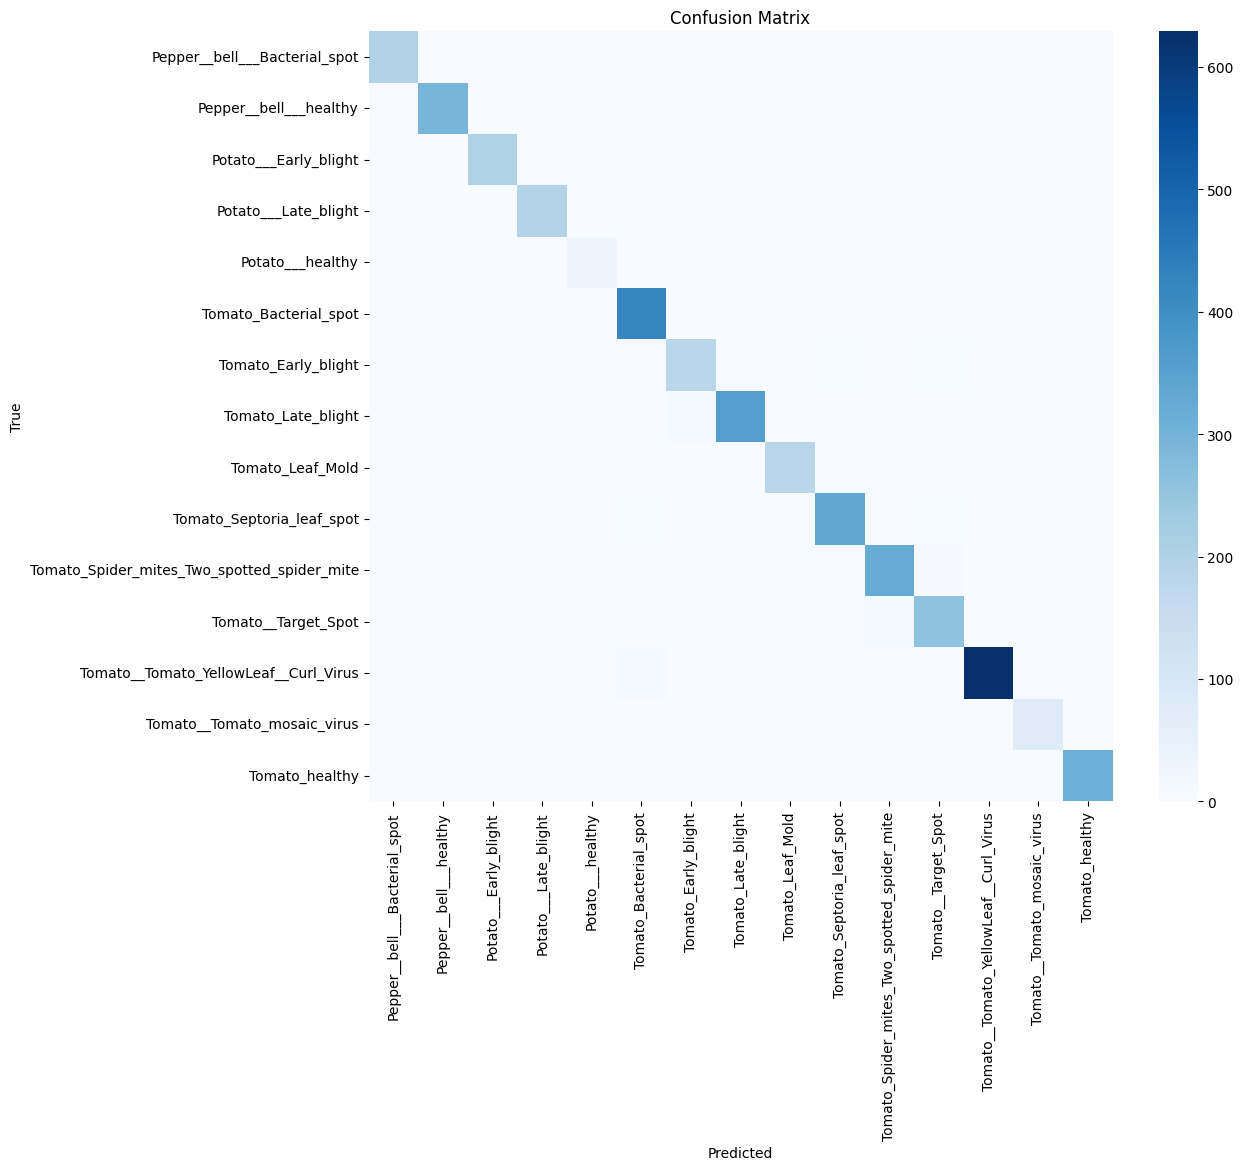

In [22]:
cm = confusion_matrix(
    y_val,
    y_pred,
    labels=list(range(num_classes))
)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [23]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create a model that maps input → last conv layer + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()


In [25]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# Pick a sample class
class_name = "Tomato__Tomato_YellowLeaf__Curl_Virus"
class_dir = os.path.join(DATA_DIR, class_name)

img_file = random.choice([
    f for f in os.listdir(class_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

img_path = os.path.join(class_dir, img_file)
print("Using image:", img_path)

# Load and preprocess image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMAGE_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)


Using image: /content/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/451819a3-0ec8-4716-bf0e-76fdb6c2353d___YLCV_NREC 2542.JPG


In [26]:
last_conv_layer_name = "top_conv"

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


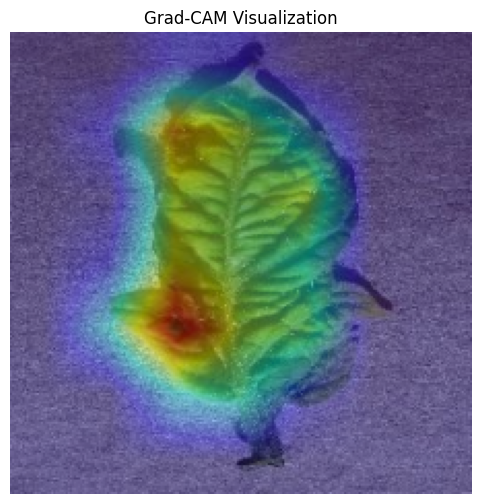

In [27]:
img = cv2.imread(img_path)
img = cv2.resize(img, IMAGE_SIZE)

heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()


In [28]:
import os

RESULTS_DIR = "/content/results/gradcam"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Saving Grad-CAMs to:", RESULTS_DIR)


Saving Grad-CAMs to: /content/results/gradcam


In [29]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), pred_index.numpy()


In [30]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

def generate_and_save_gradcam(img_path, class_name, idx):
    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Grad-CAM
    heatmap, pred_idx = make_gradcam_heatmap(
        img_array, model, last_conv_layer_name="top_conv"
    )

    # Original image for display
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, IMAGE_SIZE)

    # Resize & colorize heatmap
    heatmap = cv2.resize(heatmap, (orig.shape[1], orig.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.6, heatmap, 0.4, 0)

    # Side-by-side plot
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM\nPredicted: {class_names[pred_idx]}")
    plt.axis("off")

    save_path = os.path.join(
        RESULTS_DIR, f"gradcam_{idx}_{class_name}.png"
    )
    plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

    print("Saved:", save_path)


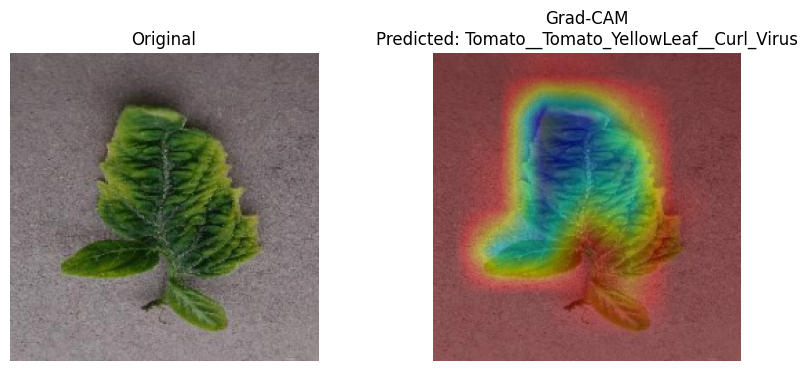

Saved: /content/results/gradcam/gradcam_1_Tomato__Tomato_YellowLeaf__Curl_Virus.png


In [31]:
import os, random

# Pick ONE class
cls = "Tomato__Tomato_YellowLeaf__Curl_Virus"
class_dir = os.path.join(DATA_DIR, cls)

img_file = random.choice([
    f for f in os.listdir(class_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

img_path = os.path.join(class_dir, img_file)

generate_and_save_gradcam(img_path, cls, idx=1)


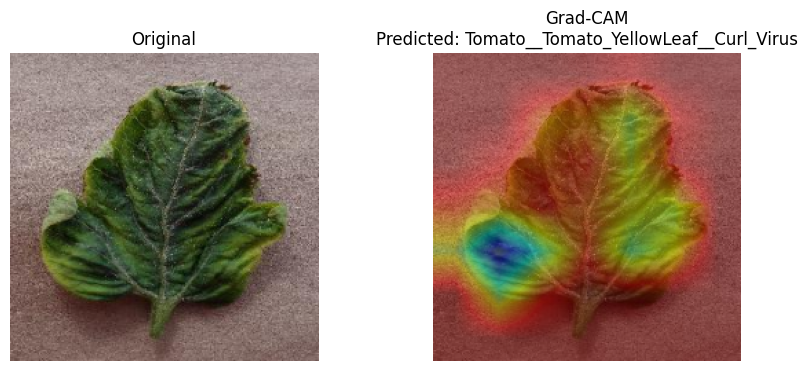

Saved: /content/results/gradcam/gradcam_1_Tomato__Tomato_YellowLeaf__Curl_Virus.png


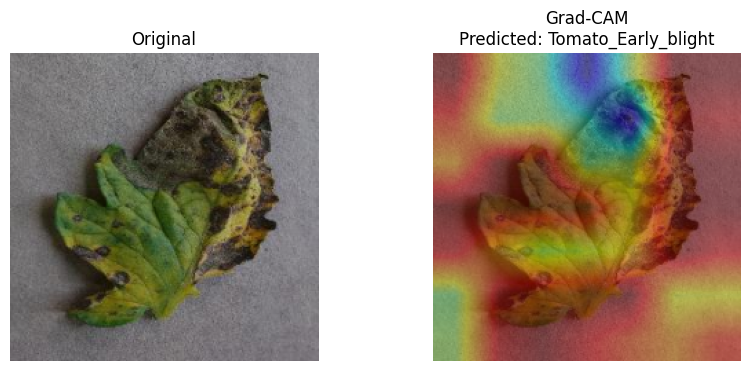

Saved: /content/results/gradcam/gradcam_2_Tomato_Early_blight.png


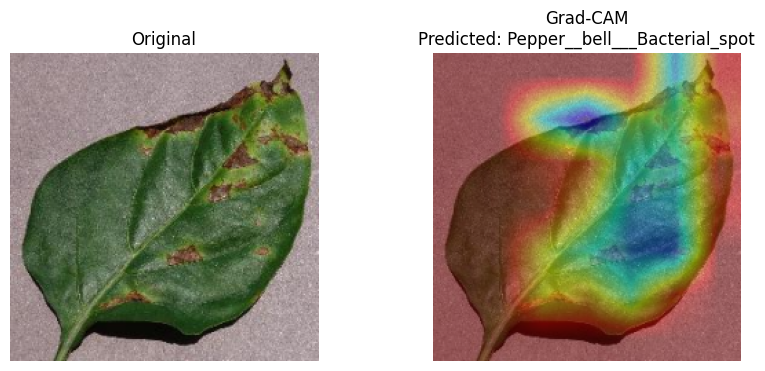

Saved: /content/results/gradcam/gradcam_3_Pepper__bell___Bacterial_spot.png


In [32]:
sample_classes = [
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato_Early_blight",
    "Pepper__bell___Bacterial_spot"
]

for i, cls in enumerate(sample_classes, start=1):
    class_dir = os.path.join(DATA_DIR, cls)
    img_file = random.choice([
        f for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    img_path = os.path.join(class_dir, img_file)

    generate_and_save_gradcam(img_path, cls, i)
